# AI-Based Intrusion Detection System using KDD Cup 99

This project builds a machine learning-based intrusion detection system to classify network traffic as either **normal** or **attack**. The workflow includes data loading, preprocessing, model training, evaluation, and feature importance analysis.

# AI-Based Intrusion Detection System using KDD Cup 99

This project builds a machine learning-based intrusion detection system to classify network traffic as either **normal** or **attack**. The workflow includes data loading, preprocessing, model training, evaluation, and feature importance analysis.

## 1. Library Installation

In this step, the required Python libraries are installed. These libraries are used for data handling, visualization, preprocessing, model training, and performance evaluation.

In [2]:
!pip install -q scikit-learn pandas matplotlib seaborn

## 2. Importing Required Libraries

The following libraries are imported to support the machine learning pipeline.  
- **Pandas** and **NumPy** are used for data manipulation.  
- **Matplotlib** is used for plotting.  
- **Scikit-learn** provides the dataset, preprocessing tools, model, and evaluation metrics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## 3. Loading the Dataset

The KDD Cup 99 dataset is loaded using scikit-learn. This dataset is a benchmark dataset for intrusion detection and contains network traffic records labeled as either normal or malicious.  

For this project, the **SA subset** is used because it is smaller and faster to work with while still being suitable for building a first intrusion detection model.

In [4]:
kdd = fetch_kddcup99(subset='SA', percent10=True, as_frame=True)

X = kdd.data.copy()
y = pd.Series(kdd.target)

print("Shape of X:", X.shape)
print("Unique target examples:", y.unique()[:10])
print(X.head())

Shape of X: (100655, 41)
Unique target examples: [b'normal.' b'smurf.' b'neptune.' b'satan.' b'back.' b'pod.' b'portsweep.'
 b'warezclient.' b'ipsweep.' b'teardrop.']
  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_count dst_host_srv_count  \
0              0      0   0  ...              9                  9   
1              0      0   0  ...             19                 19   
2              0      0   0  ...             29                 29   
3              0      0   0  ...             39                 39   
4              0      0   0  ...             49                 49  

## 4. Converting the Target into Binary Classes

The original dataset contains multiple attack labels.  
To simplify the task, the target variable is converted into two classes:

- **normal** → legitimate network traffic  
- **attack** → all malicious traffic combined into one category  

This turns the problem into a **binary classification task**.

In [5]:
# Decode byte labels if needed
y = y.apply(lambda v: v.decode('utf-8') if isinstance(v, bytes) else str(v))

# Binary target: normal vs attack
y_binary = y.apply(lambda label: 'normal' if label == 'normal.' else 'attack')

print(y_binary.value_counts())

labels
normal    97278
attack     3377
Name: count, dtype: int64


## 5. Exploring Feature Types

The dataset contains both **numerical** and **categorical** features.  
This step identifies which columns belong to each type, because they must be preprocessed differently before being used in the machine learning model.

In [6]:
print(X.dtypes)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols[:10], "... total:", len(numeric_cols))

duration                       object
protocol_type                  object
service                        object
flag                           object
src_bytes                      object
dst_bytes                      object
land                           object
wrong_fragment                 object
urgent                         object
hot                            object
num_failed_logins              object
logged_in                      object
num_compromised                object
root_shell                     object
su_attempted                   object
num_root                       object
num_file_creations             object
num_shells                     object
num_access_files               object
num_outbound_cmds              object
is_host_login                  object
is_guest_login                 object
count                          object
srv_count                      object
serror_rate                    object
srv_serror_rate                object
rerror_rate 

## 6. Cleaning Categorical Data

Some categorical values may appear as byte strings rather than standard text.  
This step converts them into readable string values so that they can be properly handled during preprocessing and one-hot encoding.

In [7]:
for col in X.columns:
    if X[col].dtype == object:
        X[col] = X[col].apply(lambda v: v.decode('utf-8') if isinstance(v, bytes) else v)

## 7. Splitting the Data into Training and Testing Sets

The dataset is divided into:
- a **training set** for learning patterns
- a **testing set** for evaluating performance on unseen data

A stratified split is used to preserve the class distribution in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (80524, 41)
Test shape: (20131, 41)


## 8. Building the Preprocessing and Modeling Pipeline

Since the dataset contains both numerical and categorical features, separate preprocessing steps are applied:

- **Numerical features**: missing value imputation and standard scaling  
- **Categorical features**: missing value imputation and one-hot encoding  

These preprocessing steps are combined into a single pipeline together with the **Random Forest classifier**.  
This ensures that the workflow is clean, reproducible, and easier to manage.

In [9]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

## 9. Training the Random Forest Model

The pipeline is trained on the training data.  
At this stage, the model learns patterns that distinguish normal network traffic from malicious traffic.

In [10]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  []),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['duration', 'protocol_type',
                                                   'service', 'flag',
                                                   'src_bytes',...
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate', ...])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

## 10. Model Evaluation

The trained model is evaluated on the test set using several performance metrics:

- **Accuracy**: overall correctness of predictions  
- **Precision**: how many predicted attacks were actually attacks  
- **Recall**: how many actual attacks were correctly detected  
- **F1-score**: balance between precision and recall  

These metrics are especially important in cybersecurity, where detecting attacks accurately is critical.

In [11]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='attack')
rec = recall_score(y_test, y_pred, pos_label='attack')
f1 = f1_score(y_test, y_pred, pos_label='attack')

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9996
Precision: 1.0
Recall   : 0.9867
F1-score : 0.9933

Classification Report:

              precision    recall  f1-score   support

      attack       1.00      0.99      0.99       675
      normal       1.00      1.00      1.00     19456

    accuracy                           1.00     20131
   macro avg       1.00      0.99      1.00     20131
weighted avg       1.00      1.00      1.00     20131



## 11. Confusion Matrix Analysis

The confusion matrix provides a detailed view of prediction outcomes:

- **True Normal**: normal traffic correctly identified  
- **False Positive**: normal traffic incorrectly labeled as attack  
- **False Negative**: attack traffic incorrectly labeled as normal  
- **True Attack**: attack traffic correctly identified  

This helps evaluate the practical usefulness of the intrusion detection system.

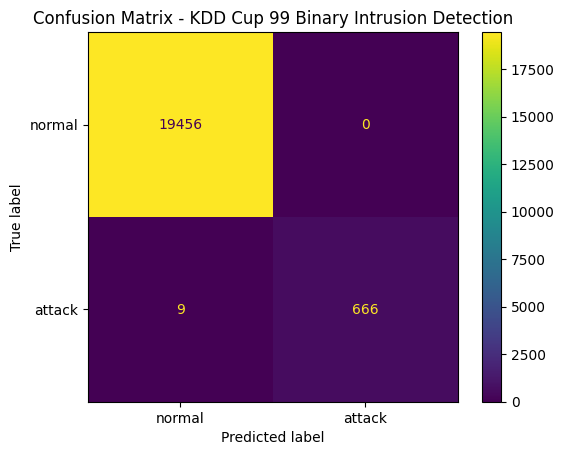

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=['normal', 'attack'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'attack'])
disp.plot()
plt.title("Confusion Matrix - KDD Cup 99 Binary Intrusion Detection")
plt.show()

## 12. Feature Importance Analysis

Random Forest can estimate the importance of each feature in making predictions.  
This step identifies which network traffic attributes contributed most to the detection of attacks.

Feature importance is useful because it adds interpretability to the model and helps reveal which traffic patterns are most strongly associated with malicious behavior.

In [13]:
rf = model.named_steps['classifier']
ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']

cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numeric_cols, cat_feature_names])

importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(15))

                               feature  importance
15212                        count_511    0.098016
2012                     service_ecr_i    0.090760
3028                    src_bytes_1032    0.079763
15568                    srv_count_511    0.069134
1998                protocol_type_icmp    0.055808
16700  dst_host_same_src_port_rate_1.0    0.036581
5062                       dst_bytes_0    0.035022
16897     dst_host_srv_serror_rate_1.0    0.021662
2534                     src_bytes_520    0.019809
15213                      srv_count_1    0.017821
16400           dst_host_srv_count_255    0.017224
2000                 protocol_type_udp    0.017163
1999                 protocol_type_tcp    0.016638
15630              srv_serror_rate_1.0    0.016253
2050                           flag_S0    0.016193


## 13. Visualizing the Most Important Features

The top 10 most important features are plotted to provide a clearer understanding of which variables had the strongest impact on the model’s decisions.

This improves interpretability and makes the results easier to communicate in a report or GitHub project.

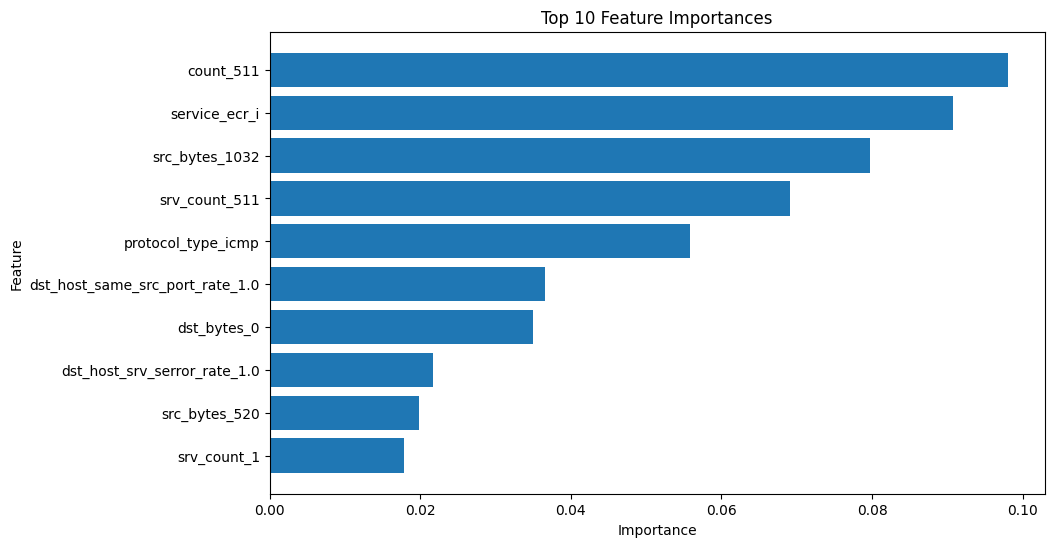

In [14]:
top10 = feat_imp.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['feature'][::-1], top10['importance'][::-1])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 14. Conclusion

This project successfully developed a machine learning-based intrusion detection system using the KDD Cup 99 dataset and a Random Forest classifier. The model achieved very strong performance in distinguishing between normal and attack traffic.

The results suggest that traffic statistics and protocol-related features are highly useful for detecting intrusions. However, the KDD Cup 99 dataset is relatively old and may not fully represent modern network traffic.

### Future Improvements
- Apply the same pipeline to a more modern dataset such as **UNSW-NB15**
- Extend the task from binary classification to **multi-class attack classification**
- Compare Random Forest with other models such as **XGBoost** or **LightGBM**